In [269]:
import pandas as pd
import csv
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy.stats import pearsonr, spearmanr

In [270]:
filename = 'data/final_enr_imr90.csv'
columns = ['diseaseId', '#snp', '#border_snp', 'pval_tad', 'pval_border', 'pval_outside', 'is_cancer', 'window_size', 'filter']
df = pd.read_csv(filename, usecols=columns)
print(df.head)

<bound method NDFrame.head of              diseaseId  #snp  #border_snp  pval_tad  pval_border  \
0          EFO_0000094    22           13  0.000000     0.000000   
1          EFO_0000095   130           72  0.000000     0.000000   
2          EFO_0000096    13            6  0.000000     0.000000   
3          EFO_0000174     7            3  0.000000     0.000000   
4          EFO_0000178    37           16  0.000000     0.000000   
...                ...   ...          ...       ...          ...   
71741    Orphanet_1945    11            0       NaN          NaN   
71742  Orphanet_391311    15            5  0.950432     0.172214   
71743     Orphanet_654     7            3  0.969582     0.088117   
71744   Orphanet_93957     3            0       NaN          NaN   
71745   Orphanet_98974     7            2  0.730591     0.294210   

       pval_outside  is_cancer  window_size     filter  
0          1.000000      False            0   nofilter  
1          1.000000      False         

In [271]:
df.shape

(71746, 9)

In [272]:
df = df[(df['#snp'] != 1) & (df['#border_snp'] != 1)]
df.shape

(52196, 9)

In [273]:
df = df[df['#border_snp'] != 0]
df.shape

(43950, 9)

In [274]:
df_cancers = pd.read_csv("data/cancerous_clustering_biogrid.csv", usecols=['efoID', 'z_score', 'pvalue', 'p_empirical'])
df_cancers = df_cancers.rename(columns={'efoID': 'diseaseId'})
df_cancers.shape

(47, 4)

In [275]:
df_noncancers = pd.read_csv("data/noncancerous_clustering_biogrid.csv", usecols=['efoID', 'z_score', 'pvalue', 'p_empirical'])
df_noncancers = df_noncancers.rename(columns={'efoID': 'diseaseId'})
df_noncancers.shape

(313, 4)

In [ ]:
def get_scatterplot(df1, filter, df2, type, window=None):
    if window is not None:
        df1 = df1[df1['window_size'] == window]
    
    df1 = df1[df1['filter'] == filter]
    combined_data = pd.merge(df1, df2, on='diseaseId', how='inner', indicator=True)
    
    df1_excluded = df1[~df1['diseaseId'].isin(combined_data['diseaseId'])]
    df2_excluded = df2[~df2['diseaseId'].isin(combined_data['diseaseId'])]

    print("\nRows from PPI Network dataset that were NOT included:")
    print(df2_excluded, f'length: {len(df2_excluded)}')
    
    print(f'number of null points: {combined_data.isnull().sum()}') 
    print(combined_data[['pval_border', 'z_score']].describe())
    combined_data = combined_data.dropna(subset=['pval_border', 'z_score'])
    
    sns.scatterplot(data=combined_data, x='pval_border', y='z_score', hue='is_cancer', palette={True: 'red', False: 'blue'}, alpha=0.5, s=30)
    plt.axvline(x=0.05, color='black', linestyle='dashed', label='P = 0.05')
    plt.axhline(y=2.0, color='black', linestyle='dashed', label='Z = 2')
    plt.xscale('log')
    plt.gca().invert_xaxis()
    plt.xlabel(f'TAD Border -log10(P-value). window: {window}, filter: {filter}')
    plt.ylabel('Z Score')
    cancer_data = combined_data[combined_data['is_cancer'] == True]
    noncancer_data = combined_data[combined_data['is_cancer'] == False]
    legend_items = [
        patches.Patch(color='red', label=f'True {len(cancer_data)}'), 
        patches.Patch(color='blue', label=f'False {len(noncancer_data)}')
        ]
    plt.legend(title='Is Cancer', handles=legend_items, loc='upper right', framealpha = 0.5)
    plt.title(f'Comparison of PPI Z score to TAD border P value. {len(combined_data)} points')

    
    if len(combined_data) >= 2:
        if len(cancer_data) >= 2 and len(noncancer_data) >= 2:
            stats = {
                "Combined Pearson": pearsonr(combined_data["pval_border"], combined_data["z_score"]),
                "Combined Spearman": spearmanr(combined_data["pval_border"], combined_data["z_score"]),
                "Cancer Pearson": pearsonr(cancer_data["pval_border"], cancer_data["z_score"]), 
                "Cancer Spearman": spearmanr(cancer_data["pval_border"], cancer_data["z_score"]),
                "Noncancer Pearson": pearsonr(noncancer_data["pval_border"], noncancer_data["z_score"]), 
                "Noncancer Spearman": spearmanr(noncancer_data["pval_border"], noncancer_data["z_score"])
            }
        else:
            stats = {
                "Combined Pearson": pearsonr(combined_data["pval_border"], combined_data["z_score"]),
                "Combined Spearman": spearmanr(combined_data["pval_border"], combined_data["z_score"])
            }
            
        table_data = [
            ["Metric", "r", "p"]
        ]
        
        for key, value in stats.items():
            table_data.append([key, f"{value[0]:.5f}", f"{value[1]:.3e}"])

        table = plt.table(cellText=table_data, colLabels=None, cellLoc='center', loc='bottom', bbox=[0, -0.5, 1, 0.3])
        table.auto_set_font_size(False)
        table.set_fontsize(8)
        table.scale(1, 1.2)
        
        

    plt.savefig(f'results_graphs_biogrid/{type}/comparison_{type}_{window}_{filter}.png', dpi=300, bbox_inches='tight')
    plt.show()

In [276]:
def get_region_counts(df):
    region_11 = (df['z_score'] >= 2) & (df['pval_border'] < 0.05)
    region_01 = (df['z_score'] < 2) & (df['pval_border'] < 0.05)
    region_10 = (df['z_score'] >= 2) & (df['pval_border'] >= 0.05)
    region_00 = (df['z_score'] < 2) & (df['pval_border'] >= 0.05)

    
    region_11_count = np.sum(region_11)
    region_01_count = np.sum(region_01)
    region_10_count = np.sum(region_10)
    region_00_count = np.sum(region_00)
    
    num = {'11': region_11_count, '01': region_01_count, '10': region_10_count, '00': region_00_count}
    diff = (num['01'] + num['10']) - num['11']
    
    return num

In [277]:
def shuffle_analysis(df1, df2):
    combined_data = pd.merge(df1, df2, on='diseaseId', how='inner', indicator=True)
    combined_data = combined_data[combined_data['is_cancer'] == False]
    pval_shuffled = np.random.permutation(combined_data['pval_border'].values)
    z_shuffled = np.random.permutation(combined_data['z_score'].values)
    
    shuffled_df = combined_data.copy()
    shuffled_df['pval_border'] = pval_shuffled
    shuffled_df['z_score'] = z_shuffled
    
    num = get_region_counts(shuffled_df)
    
    return num

In [278]:
combined = pd.concat([df_cancers, df_noncancers])
mask = combined['pvalue'] == 0.0
combined.loc[mask, 'pvalue'] = combined.loc[mask, 'p_empirical']
combined.head

<bound method NDFrame.head of          diseaseId    z_score  pvalue  p_empirical
0      EFO_0004193  13.098661     NaN     0.000999
1      EFO_0000707   5.391684     NaN     0.011988
2      EFO_0010176   9.102589     NaN     0.001998
3      EFO_0000389  19.820597     NaN     0.000999
4    MONDO_0005575   3.947404     NaN     0.005994
..             ...        ...     ...          ...
308    EFO_0009598   1.439829     NaN     0.068931
309    EFO_0009594   0.761575     NaN     0.099900
310    EFO_0009597   0.919701     NaN     0.066933
311    EFO_0010684   5.502696     NaN     0.004995
312    EFO_1001180   1.749875     NaN     0.023976

[360 rows x 4 columns]>

In [ ]:
filters = ['nofilter', 'exonic', 'intronic', 'intergenic', 'nonexonic']
actual_num = {}

for filter in filters:
    df1 = df[df['filter'] == filter]
    combined_data = pd.merge(df1, combined, on='diseaseId', how='inner', indicator=True)
    
    num = get_region_counts(combined_data[combined_data['is_cancer'] == False])
    print(num)
    actual_num[filter] = num



In [ ]:
shuffled_11 = {}
shuffled_01 = {}
shuffled_10 = {}
shuffled_00 = {}
filters = ['nofilter', 'exonic', 'intronic', 'intergenic', 'nonexonic']

for filter in filters:
    shuffled_11[filter] = []
    shuffled_01[filter] = []
    shuffled_10[filter] = []
    shuffled_00[filter] = []
    for i in range(10000):
        df1 = df[df['filter'] == filter]
        num = shuffle_analysis(df1, combined)
        shuffled_11[filter].append(num['11'])
        shuffled_01[filter].append(num['01'])
        shuffled_10[filter].append(num['10'])
        shuffled_00[filter].append(num['00'])

In [ ]:
len(shuffled_01['exonic'])

In [ ]:
shuffled_data = {}
for filter in filters:
    shuffled_data[filter] = {}
    shuffled_data[filter]['00'] = shuffled_00[filter] 
    shuffled_data[filter]['10'] = shuffled_10[filter]
    shuffled_data[filter]['01'] = shuffled_01[filter] 
    shuffled_data[filter]['11'] = shuffled_11[filter]

In [279]:
def get_zscores(shuffled_data, num):
    zscore_regions = {}
    for filter in shuffled_data.keys():
        zscore_regions[filter] = {}
        for region in shuffled_data[filter].keys():
            mean = np.mean(shuffled_data[filter][region])
            std = np.std(shuffled_data[filter][region])
            print(mean, std)
            if std == 0:
                zscore_regions[filter][region] = np.nan
            else:
                zscore_regions[filter][region] = (num[filter][region] - mean) / std
    return zscore_regions

In [ ]:
zscore_regions = get_zscores(shuffled_data, actual_num)
zscore_regions

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec

def plot_regions_cleaned(shuffled_data, actual_num, z_scores, path):
    sns.set(style="whitegrid")
    filters = ['nofilter', 'exonic', 'intronic', 'intergenic', 'nonexonic']
    regions = {
        '00': 'Z−, P−',
        '01': 'Z−, P+',
        '10': 'Z+, P−',
        '11': 'Z+, P+'
    }

    for filter in filters:
        fig = plt.figure(figsize=(12, 10))
        spec = gridspec.GridSpec(2, 2, hspace=0.4, wspace=0.3)
        fig.suptitle(f"SNP-TAD Enrichment Distribution — Filter: {filter.capitalize()}", fontsize=18, fontweight='bold')

        for i, (region, label) in enumerate(regions.items()):
            ax = fig.add_subplot(spec[i])
            sns.histplot(shuffled_data[filter][region], bins=30, kde=True, ax=ax,
                         color='#4878CF', edgecolor='black', alpha=0.7)

            ax.axvline(actual_num[filter][region], color="#D65F5F", linestyle="--", linewidth=2,
                       label=f"Actual Count: {actual_num[filter][region]}")

            ax.set_title(f"Region {region} ({label}) — Z: {z_scores[filter][region]:.2f}", fontsize=12)
            ax.set_xlabel("Edge Count", fontsize=11)
            ax.set_ylabel("Frequency", fontsize=11)
            ax.legend(loc='upper left', frameon=True)

        plt.savefig(f"{path}/{filter}_cleaned.png", dpi=300, bbox_inches='tight')
        plt.close()


In [ ]:
def plot_regions_matrix(shuffled_data, actual_num, z_scores, path,
                         bins=30, kde=True, palette="#4878CF"):

    sns.set(style="whitegrid")
    filters = ['exonic', 'intronic', 'intergenic', 'nonexonic']
    filter_labels = [f.capitalize() for f in filters]

    regions = ['00', '01', '10', '11']
    region_labels = ['Z−,P−', 'Z−,P+', 'Z+,P−', 'Z+,P+']

    # Make one big figure
    n_rows, n_cols = len(filters), len(regions)
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(n_cols*3.2, n_rows*2.6),
                             sharex=False, sharey=False)

    for r, flt in enumerate(filters):
        for c, reg in enumerate(regions):
            ax = axes[r, c]
            sns.histplot(shuffled_data[flt][reg],
                         bins=bins, kde=kde, ax=ax,
                         color=palette, edgecolor='black', alpha=0.7)

            # Vertical line for actual edge‑count
            ax.axvline(actual_num[flt][reg],
                       color="#D65F5F", linestyle="--", linewidth=1.8)

            # Titles and labels
            if r == 0:      # top row → column headers
                ax.set_title(region_labels[c], fontsize=11, pad=6)
            if c == 0:      # first col → row labels
                ax.set_ylabel(f"{filter_labels[r]}\nFrequency", fontsize=10)
            else:
                ax.set_ylabel("")

            ax.set_xlabel("Edge count", fontsize=9)
            # Embed z‑score inside the axes (top‑left corner)
            ax.text(0.02, 0.92, f"z={z_scores[flt][reg]:.2f}",
                    transform=ax.transAxes, fontsize=8,
                    ha="left", va="top",
                    bbox=dict(boxstyle="round,pad=0.15",
                              facecolor="white", alpha=0.6, lw=0))

    fig.suptitle("SNP-TAD Enrichment - Shuffled vs. Actual",
                 fontsize=16, weight='bold', y=1.02)
    plt.tight_layout()
    #fig.savefig(f"{path}/labels_biogrid_imr90.png", dpi=300,
               # bbox_inches='tight')
    #plt.close(fig)


In [ ]:
plot_regions_matrix(shuffled_data, actual_num, zscore_regions, 'plots/')

In [ ]:
plot_regions_cleaned(shuffled_data, actual_num, zscore_regions, 'results_graphs/shuffled_regions_cleaned')

In [ ]:
region_labels = {'00': 'Z−,P−', '01': 'Z−,P+', '10': 'Z+,P−', '11': 'Z+,P+'}

In [ ]:
flat_rows = [
    {'Filter': filter_name, 'Region': region_labels[region], 'z_score': z}
    for filter_name, region_dict in zscore_regions.items()
    for region, z in region_dict.items()
]

zscore_df = pd.DataFrame(flat_rows)

zscore_df = zscore_df[zscore_df['Filter'] != 'nofilter']

In [280]:
def plot_reg_z_scores(zscore_df, path=None):
    filters = ['exonic', 'intronic', 'intergenic', 'nonexonic']
    filter_labels = [f.capitalize() for f in filters]
    
    palette = ['brown', 'indianred', 'salmon', 'mistyrose']

    plt.figure(figsize=(6,3))
    
    err_kws={'color': '0.2', 'linewidth': '2.5'}
    

    ax = sns.barplot(data=zscore_df, x='Region', y='z_score', capsize=0.5, edgecolor ='0.2', lw = 2.5, err_kws=err_kws, hue='Filter', palette=palette)
    for axis in ['bottom', 'left']:
        ax.spines[axis].set_linewidth(2.5)
        ax.spines[axis].set_color('0.2')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(False)
    ax.axhline(0, linewidth=2, color='0.2')

    plt.xticks(size = 14, rotation= 35, rotation_mode = 'anchor', ha='center', weight='bold', color='0.2')
    plt.yticks(size = 14, weight='bold', color='0.2')
    ax.tick_params(width=2.5, color='0.2', direction='inout', length=10)
    plt.xlabel('')
    plt.ylabel('Z-scores', size=14, weight='bold', color='0.2')
    plt.legend(loc = 10, bbox_to_anchor = (0.5, -0.33), ncol = 2, frameon = False, fontsize = 16, labelcolor='0.2', prop={'weight': 'bold'})
    
    
    
    #ax = sns.swarmplot(data=zscores_df, x='Filter', y='z_score', marker='s', s=10)

In [ ]:
plot_reg_z_scores(zscore_df)

### Shuffling Cancer/Noncancer Labels and getting region distributions

In [281]:
merged_df = pd.merge(df, combined, on='diseaseId', how='inner', indicator=True)
original_num = {}
sums = {}

filters = ['nofilter', 'exonic', 'intronic', 'intergenic', 'nonexonic']

original_num['cancer'] = {}
original_num['noncancer'] = {}

for filter in filters:
    original_num['cancer'][filter] = {}
    original_num['noncancer'][filter] = {}
    sums[filter] = {}
    df_filtered = merged_df[merged_df['filter'] == filter]
    cancers_num = (df_filtered['is_cancer'] == True).sum()
    noncancers_num = (df_filtered['is_cancer'] == False).sum()
    sums[filter]['cancer'] = cancers_num
    sums[filter]['noncancer'] = noncancers_num
    
    df_cancers = df_filtered[df_filtered['is_cancer'] == True]
    df_noncancers = df_filtered[df_filtered['is_cancer'] == False]
    
    cancer_output = get_region_counts(df_cancers)
    noncancer_output = get_region_counts(df_noncancers)
    original_num['cancer'][filter] = cancer_output
    original_num['noncancer'][filter] = noncancer_output

sums, original_num
    
    

({'nofilter': {'cancer': np.int64(669), 'noncancer': np.int64(3884)},
  'exonic': {'cancer': np.int64(385), 'noncancer': np.int64(2150)},
  'intronic': {'cancer': np.int64(627), 'noncancer': np.int64(3672)},
  'intergenic': {'cancer': np.int64(558), 'noncancer': np.int64(3434)},
  'nonexonic': {'cancer': np.int64(647), 'noncancer': np.int64(3844)}},
 {'cancer': {'nofilter': {'11': np.int64(235),
    '01': np.int64(3),
    '10': np.int64(308),
    '00': np.int64(123)},
   'exonic': {'11': np.int64(171),
    '01': np.int64(17),
    '10': np.int64(182),
    '00': np.int64(15)},
   'intronic': {'11': np.int64(196),
    '01': np.int64(8),
    '10': np.int64(314),
    '00': np.int64(109)},
   'intergenic': {'11': np.int64(96),
    '01': np.int64(1),
    '10': np.int64(344),
    '00': np.int64(117)},
   'nonexonic': {'11': np.int64(229),
    '01': np.int64(3),
    '10': np.int64(292),
    '00': np.int64(123)}},
  'noncancer': {'nofilter': {'11': np.int64(1079),
    '01': np.int64(216),
    '1

In [282]:
def shuffle_labels(df, sums):
    label_shuffled = np.random.permutation(df['is_cancer'].values)
        
    shuffled_df = df.copy()
    shuffled_df['is_cancer'] = label_shuffled
    assert((shuffled_df['is_cancer'] == True).sum() == sums['cancer'])
    assert((shuffled_df['is_cancer'] == False).sum() == sums['noncancer'])
    
    shuffled_cancer = shuffled_df[shuffled_df['is_cancer'] == True]
    shuffled_noncancer = shuffled_df[shuffled_df['is_cancer'] == False]
        
    cancer, noncancer = get_region_counts(shuffled_cancer), get_region_counts(shuffled_noncancer)
        
    return cancer, noncancer

In [283]:
shuffled_regions_cancer = {}
shuffled_regions_noncancer = {}
regions = ['00', '01', '10', '11']

for filter in filters:
    shuffled_regions_cancer[filter] = {'00' : [], '01': [], '10': [], '11': []}
    shuffled_regions_noncancer[filter] = {'00' : [], '01': [], '10': [], '11': []}
    
    df_filtered = merged_df[merged_df['filter'] == filter]
    
    for i in range(10000):
        cancer, noncancer = shuffle_labels(df_filtered, sums[filter])
        for region in regions:
            shuffled_regions_cancer[filter][region].append(cancer[region])
            shuffled_regions_noncancer[filter][region].append(noncancer[region])
            

shuffled_regions_cancer, shuffled_regions_noncancer

({'nofilter': {'00': [np.int64(182),
    np.int64(185),
    np.int64(178),
    np.int64(186),
    np.int64(189),
    np.int64(187),
    np.int64(198),
    np.int64(204),
    np.int64(167),
    np.int64(175),
    np.int64(180),
    np.int64(167),
    np.int64(175),
    np.int64(157),
    np.int64(175),
    np.int64(170),
    np.int64(187),
    np.int64(184),
    np.int64(169),
    np.int64(175),
    np.int64(185),
    np.int64(186),
    np.int64(192),
    np.int64(186),
    np.int64(178),
    np.int64(175),
    np.int64(176),
    np.int64(178),
    np.int64(188),
    np.int64(181),
    np.int64(189),
    np.int64(178),
    np.int64(172),
    np.int64(192),
    np.int64(212),
    np.int64(193),
    np.int64(174),
    np.int64(175),
    np.int64(189),
    np.int64(187),
    np.int64(187),
    np.int64(180),
    np.int64(205),
    np.int64(172),
    np.int64(186),
    np.int64(173),
    np.int64(182),
    np.int64(184),
    np.int64(168),
    np.int64(196),
    np.int64(168),
    np.int64(

In [284]:
len(shuffled_regions_cancer['nofilter']['00'])

10000

In [285]:
zscore_regions_cancers = get_zscores(shuffled_regions_cancer, original_num['cancer'])
zscore_regions_noncancers = get_zscores(shuffled_regions_noncancer, original_num['noncancer'])

182.68 10.611993215225874
32.157 5.1529943722072895
261.1806 11.785982506350498
192.9824 10.757364465332575
45.3926 5.900276708765445
56.4939 6.457968936902685
133.3633 8.649018043107551
149.7502 8.752736712594524
159.9282 10.146755380908717
35.3255 5.36206580992811
263.7802 11.406274061234896
167.9661 10.273721370078128
168.2595 10.138212847933307
5.748 2.2274415817255453
300.0895 11.009191148762927
83.903 7.865658967944135
183.6013 10.656225331232443
22.4305 4.329453747298843
262.7596 11.582331709979645
178.2086 10.503546355398257
1059.32 10.611993215225874
186.843 5.1529943722072895
1516.8194 11.7859825063505
1121.0176 10.757364465332575
253.6074 5.900276708765445
315.5061 6.457968936902685
744.6367 8.649018043107553
836.2498 8.752736712594524
937.0718 10.146755380908717
206.6745 5.36206580992811
1544.2198 11.406274061234894
984.0339 10.273721370078126
1034.7405 10.138212847933307
35.252 2.2274415817255453
1847.9105 11.009191148762929
516.097 7.865658967944136
1091.3987 10.656225331

In [ ]:
zscore_regions_cancers

### Plots for Shuffled Labels (Cancer/Noncancer)

In [ ]:
plot_regions_matrix(shuffled_regions_cancer, original_num['cancer'], zscore_regions_cancers, 'plots/')

In [286]:
flat_rows = [
    {'Filter': filter_name, 'Region': region_labels[region], 'z_score': z}
    for filter_name, region_dict in zscore_regions_cancers.items()
    for region, z in region_dict.items()
]

zscore_cancers_df = pd.DataFrame(flat_rows)

zscore_cancers_df = zscore_cancers_df[zscore_cancers_df['Filter'] != 'nofilter']

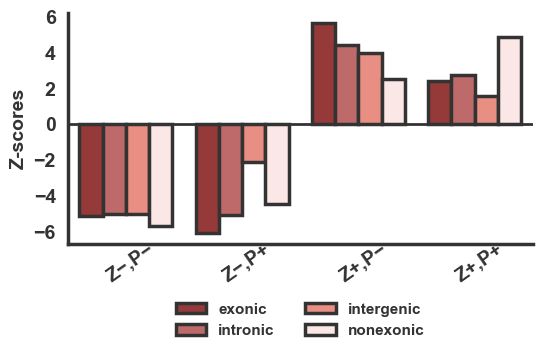

In [287]:
plot_reg_z_scores(zscore_cancers_df)

In [ ]:
plot_regions_matrix(shuffled_regions_noncancer, original_num['noncancer'], zscore_regions_noncancers, 'results_graphs/shuffled_labels/noncancer')

### Plotting the z-scores as a function of the window parameter

In [ ]:
# shuffled regions

filters = ['nofilter', 'exonic', 'intronic', 'intergenic', 'nonexonic']
actual_num = {}


for filter in filters:
    df_filter = df[df['filter'] == filter]
    actual_num[filter] = {}
    for i in range(0, 21):
        df_window = df_filter[df_filter['window_size'] == i]
        combined_data = pd.merge(df_window, combined, on='diseaseId', how='inner', indicator=True)
        
        num = get_region_counts(combined_data)
        actual_num[filter][i] = num

actual_num


In [ ]:
shuffled_window_num = {}
filters = ['nofilter', 'exonic', 'intronic', 'intergenic', 'nonexonic']

for filter in filters:
    shuffled_window_num[filter] = {}
    df_filter = df[df['filter'] == filter]
    for i in range(0, 21):
        shuffled_window_num[filter][i] = {'00' : [], '01': [], '10': [], '11': []}
        for j in range(10000):
            num = shuffle_analysis(df_filter, combined)
            shuffled_window_num[filter][i]['11'].append(num['11'])
            shuffled_window_num[filter][i]['00'].append(num['00'])
            shuffled_window_num[filter][i]['10'].append(num['10'])
            shuffled_window_num[filter][i]['01'].append(num['01'])
shuffled_window_num

In [ ]:
shuffled_window_num['exonic'][15]

In [ ]:
def get_zscores_windows(shuffled_data, num):
    zscore_regions = {}
    for window in shuffled_data.keys():
        zscore_regions[window] = {}
        for region in shuffled_data[window].keys():
            mean = np.mean(shuffled_data[window][region])
            std = np.std(shuffled_data[window][region])
            print(mean, std)
            if std == 0:
                zscore_regions[window][region] = np.nan
            else:
                zscore_regions[window][region] = (num[window][region] - mean) / std
    return zscore_regions

In [ ]:
z_scores_windows = {}
for filter in filters:
    z_scores_regions = get_zscores_windows(shuffled_window_num[filter], actual_num[filter])
    z_scores_windows[filter] = z_scores_regions

z_scores_windows

In [ ]:
z_scores_windows['intergenic']

In [ ]:
def plot_regions_windows(shuffled_data, actual_num, z_scores, path):
    filters = ['nofilter', 'exonic', 'intronic', 'intergenic', 'nonexonic']
    regions = ['00', '01', '10', '11']
    
    for filter in filters:
        figure, axes = plt.subplots(2, 2, figsize=(10, 8))
        figure.suptitle(f"Region Counts as a function of Window Sizes", fontsize=16)
        
        axes = axes.flatten()
        
        for i, region in enumerate(regions):
            axes[i].plot(z_scores.keys(), z_scores)
            axes[i].set_title(f"Region {region}, z_score: {z_scores[filter][region]:.2f}")
            axes[i].axvline(actual_num[filter][region], color="red", linestyle="dashed", label=f"Actual Count: {actual_num[filter][region]}")
            axes[i].legend()

        plt.tight_layout()
        plt.savefig(f'{path}/{filter}.png', dpi=300, bbox_inches='tight')
        plt.show()

### Scatterplots

In [ ]:
filters = ['nofilter', 'exonic', 'intronic', 'intergenic', 'nonexonic']
for i in filters:
    get_scatterplot(df, i, combined, 'combined')

In [ ]:
def get_network_scatterplot(df1, type):
    sns.scatterplot(data=df1, x='pvalue', y='z_score', hue='is_cancer', palette={True: 'red', False: 'blue'}, alpha=0.5, s=30)
    plt.ylim(-5, 70)  
    plt.axvline(x=0.05, color='black', linestyle='dashed', label='P = 0.05')
    plt.xscale('log')
    plt.gca().invert_xaxis()
    plt.xlabel('P Value')
    plt.ylabel('Z Score')
    plt.title(f'Comparison of PPI Network Z score to P value. {len(df1)} points')
    
    cancer_data = df1[df1["is_cancer"] == True]
    noncancer_data = df1[df1["is_cancer"] == False]
    legend_items = [
        patches.Patch(color='red', label=f'True {len(cancer_data)}'), 
        patches.Patch(color='blue', label=f'False {len(noncancer_data)}')]
    plt.legend(title='Is Cancer', handles=legend_items, loc='upper left', framealpha = 0.5)
    
    if len(df1) >= 2:
        if len(cancer_data) >= 2 and len(noncancer_data) >= 2:
            stats = {
                "Combined Pearson": pearsonr(df1["pvalue"], df1["z_score"]),
                "Combined Spearman": spearmanr(df1["pvalue"],df1["z_score"]),
                "Cancer Pearson": pearsonr(cancer_data["pvalue"], cancer_data["z_score"]), 
                "Cancer Spearman": spearmanr(cancer_data["pvalue"], cancer_data["z_score"]),
                "Noncancer Pearson": pearsonr(noncancer_data["pvalue"], noncancer_data["z_score"]), 
                "Noncancer Spearman": spearmanr(noncancer_data["pvalue"], noncancer_data["z_score"])
            }
        else:
            stats = {
                "Combined Pearson": pearsonr(df1["pvalue"], df1["z_score"]),
                "Combined Spearman": spearmanr(df1["pvalue"], df1["z_score"])
            }
            
        table_data = [
            ["Metric", "r", "p"]
        ]
        
        for key, value in stats.items():
            table_data.append([key, f"{value[0]:.5f}", f"{value[1]:.3e}"])

        table = plt.table(cellText=table_data, colLabels=None, cellLoc='center', loc='bottom', bbox=[0, -0.5, 1, 0.3])
        table.auto_set_font_size(False)
        table.set_fontsize(8)
        table.scale(1, 1.2)
    
    plt.savefig(f'results_graphs/network_graphs/comparison_{type}.png', dpi=300, bbox_inches='tight')
    plt.show()


In [ ]:
get_network_scatterplot(combined, 'combined')